# Toy System — 3D Version

## System Definition

Let  

$$
E_R = \{ x \in \mathbb{R}^3 : \|x\| \le R \}
$$  

and let $\nu$ be a probability measure supported on $E_1$ (the regime).  
We consider the process $(X_t)_{t \ge 0}$  evolving in $E_2$ with **reinsertion** occurring whenever the system’s radius exceeds $2$.
- **Flow** For $x \in \mathbb{R}^3$, define the deterministic flow  

$$
\dot{x} = f(x) = x, \qquad 
\phi(t, x) = x e^{t}.
$$

Each component satisfies $\dot{x}_i = x_i$, and therefore the norm evolves as  

$$
\|\phi(t, x)\| = \|x\| e^{t}.
$$


- **Boundary Hitting Time** The time it takes for a point $x$ to reach the boundary of radius $1$ is  

$$
\tau(x)
= \inf \{ t > 0 : \|\phi(t, x)\| = 1 \}
= \ln \!\left( \frac{1}{\|x\|} \right), \qquad x \ne 0,
$$  

and $\tau(0) = +\infty$.  

- **Reinsertion Rule** Whenever the process transgresses the boundary $\partial E_2$ it is **instantaneously reset** to a random point drawn from the reinsertion measure $\nu$, independently of the past:

$$
X_t \sim \nu.
$$

In [1]:
import numpy as np
import cdv_utils
import matplotlib.pyplot as plt
import importlib
from scipy import sparse
import pickle
importlib.reload(cdv_utils)
plt.rcParams['text.usetex'] = True
plt.rcParams['pgf.texsystem'] = "pdflatex"
plt.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath,amsfonts,amssymb,cmbright,standalone}')

In [2]:
from cdv_utils import (plot_lifetime_distributions_lines, diffusion_maps_matrix, calculate_escape_times,
                       expected_escape_times_from_TO, add_scaled_top_axis, spy_col,
                       simulate_trajectories_per_sigma_3d, normal_reset_sampler_vectorized_3d,
                       plot_multiple_sigmas, plot_trajectory_with_reinsertions_3d,
                       compute_lifetimes_per_sigma_3d, mean_escape_times_via_reinsertion_radius3d,
                       solve_escape_from_Q, plot_means_with_inset, make_L3d,
                       visualize_sphere_sampling, scatter_sphere_sampling,
                       direction_homogeneity_ratio, direction_homogeneity_metric,
                       add_radius_histogram_to_right, affinity_entry_sum,
                       plot_loglog_slope_analysis)

In [3]:
rng = np.random.default_rng(420)
dt = 1e-2
save_every = 1

In [4]:
times, states, sigma_arr = simulate_trajectories_per_sigma_3d(
    sigmas=np.array([0.1], dtype=np.float32),
    dt=dt,
    n_steps=int(1e3) - 1,
    reset_sampler=normal_reset_sampler_vectorized_3d,
    rng=rng,
    save_every=save_every,
    x0=np.array([0.01, 0.01, 0.01],),
    dtype=np.float32
)

(0.0, 9.99)

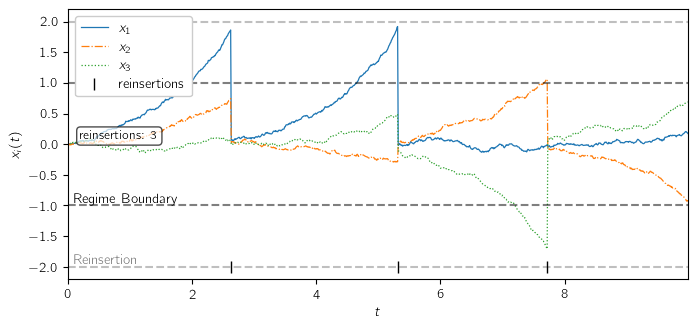

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
reset_times_per_path = [
    times[np.linalg.norm(states[:, j, :], axis=1) > 2.0]
    for j in range(states.shape[1])]
plot_trajectory_with_reinsertions_3d(
    ax, times, states, reset_times_per_path[0])
ax.set_xlim(0, times[-1])

In [160]:
sigmas = np.linspace(0.0, 0.3, 101, dtype=np.float32)

times, states, sigma_arr = simulate_trajectories_per_sigma_3d(
    sigmas=sigmas,
    dt=dt,
    n_steps=int(1e3) - 1,
    reset_sampler=normal_reset_sampler_vectorized_3d,
    rng=rng,
    save_every=save_every,
    x0=np.array([0.05, 0.05, 0.05],),
    dtype=np.float32
)

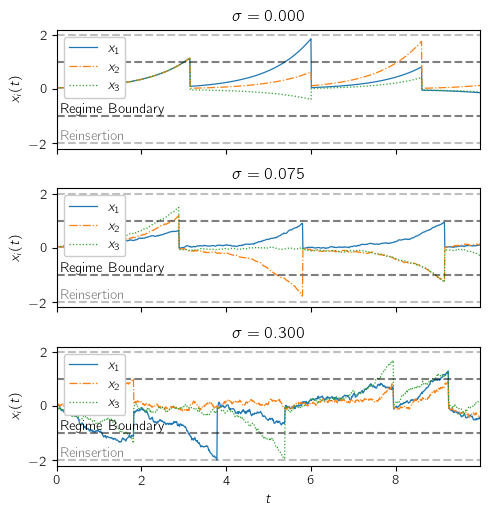

In [7]:
reset_times_per_path = [
    times[np.linalg.norm(states[:, j, :], axis=1) > 2.0]
    for j in [0, 25, 100]
]

fig, ax = plot_multiple_sigmas(times, states[:, [0, 25, 100], :],
                               np.quantile(sorted(sigma_arr),
                                           [0, 0.25, 1]),
                               n_cols=1, figsize=(5, 1.75),
                               reset_times_per_path=reset_times_per_path,
                               in3d=True, show_reinserts=False)
for axis in ax:
    axis.set_xlim(0, times[-1])
plt.savefig("../../Toy3dTrajs.pdf", bbox_inches="tight", dpi=600)

## For individual points
### Monte Carlo Method

In [44]:
sigmas = sigmas[:20]

In [50]:
reinsertion_radii = np.linspace(0.01, 0.1, 4)
means, counts = mean_escape_times_via_reinsertion_radius3d(sigmas=sigmas,
                                                           reinsertion_radius=reinsertion_radii,
                                                           dt=dt,
                                                           n_steps=int(1e6)-1,
                                                           rng=rng,
                                                           save_every=save_every,
                                                           dtype=np.float32)

### Markov Chain method

In [61]:
def fibonacci_sphere(n_points=100, radius=1e-4):
    """
    Deterministic, nearly-uniform distribution of points on a sphere.
    No randomness. Good equal-area spacing.
    """
    points = np.zeros((n_points, 3))
    phi = np.pi * (3. - np.sqrt(5.))   # golden angle

    for i in range(n_points):
        y = 1 - (2.0 * i) / (n_points - 1)   # from 1 to -1
        r = np.sqrt(1 - y*y)
        theta = phi * i

        x = r * np.cos(theta)
        z = r * np.sin(theta)

        points[i] = radius * np.array([x, y, z])

    return points


# Example:
points = fibonacci_sphere(350, 2e-3)

In [62]:
# compute trajectories once and reuse for all reinsertion radii
dt_higher = 1e-1

# simulate once for all starting points and collect per-point norms and lengths
traj_list = []
norms_list = []
lengths = []
for x_i in points:
    times, states, sigma_arr = simulate_trajectories_per_sigma_3d(
        sigmas=np.array([0.0], dtype=np.float32),
        dt=dt_higher,
        n_steps=int(1e3) - 1,
        reset_sampler=normal_reset_sampler_vectorized_3d,
        rng=rng,
        save_every=save_every,
        x0=x_i,
        dtype=np.float32
    )
    first_reset = np.where(np.linalg.norm(states, axis=-1) > 2.0)[0]
    cut = first_reset[0]
    traj_list.append(states[:cut, :, :])
    # per-point norms (first ensemble member)
    norms_list.append(np.linalg.norm(states[:cut, 0, :], axis=-1))
    lengths.append(cut)

full_traj = np.concatenate(traj_list, axis=0)
offsets = np.cumsum([0] + lengths[:-1]).astype(np.int64)
times = np.linspace(
    0, dt_higher * (full_traj.shape[0] - 1), full_traj.shape[0])
blocking_mask = (np.linalg.norm(
    full_traj[:-1, 0, :], axis=-1) < 1.0).ravel().astype(bool)

eps_values = (2.0 * dt_higher * sigmas**2)

In [63]:
full_traj.shape

(24500, 1, 3)

In [64]:
# 70 min
# heavy linear-algebra: compute L and t_escape once per eps and store
t_escape_mat = np.empty((sigmas.size, blocking_mask.sum()), dtype=np.float64)
for j, eps in enumerate(eps_values):
    print(f"{j}th eps: {eps}")
    L = make_L3d(full_traj[:, 0, :], eps)
    Q = L[blocking_mask][:, blocking_mask].tocsr()
    t_escape = solve_escape_from_Q(Q)
    t_escape_mat[j, :] = t_escape

0th eps: 0.0
[sparse-direct] used splu (n=22050, nnz=21700, density=4.463e-05).
1th eps: 1.8000000636675395e-06
[sparse-direct] used splu (n=22050, nnz=5418422, density=0.01114).
2th eps: 7.200000254670158e-06
[sparse-direct] used splu (n=22050, nnz=21947029, density=0.04514).
3th eps: 1.619999784452375e-05
[iterative] GMRES converged with ILU preconditioner (n=22050, nnz=37577916, density=0.07729).
4th eps: 2.8800001018680632e-05
[iterative] GMRES converged with ILU preconditioner (n=22050, nnz=51182618, density=0.1053).
5th eps: 4.5000000682193786e-05
[iterative] GMRES converged with ILU preconditioner (n=22050, nnz=63158888, density=0.1299).
6th eps: 6.4799991378095e-05
[iterative] GMRES converged with ILU preconditioner (n=22050, nnz=73863152, density=0.1519).
7th eps: 8.819999493425712e-05
[iterative] GMRES converged with ILU preconditioner (n=22050, nnz=83544344, density=0.1718).
8th eps: 0.00011520000407472253
[iterative] GMRES converged with ILU preconditioner (n=22050, nnz=924

In [65]:

# now fill reinsert_TO by mapping reinsertion radii to indices and averaging precomputed t_escape
reinsert_TO = np.empty((sigmas.size, reinsertion_radii.size), dtype=np.float64)
for i, R in enumerate(reinsertion_radii):
    print(f"Reinsertion radius {R}")
    # compute reinsertion time indices (full-traj indices) for each starting point
    rp_full = np.empty(len(norms_list), dtype=np.int64)
    for k, norms in enumerate(norms_list):
        rp_full[k] = np.argmin(np.abs(norms - R)) + offsets[k]

    rp_in_blocking = np.nonzero(np.isin(np.nonzero(blocking_mask)[0], rp_full))[
        0]  # indices into blocking_mask
    if rp_in_blocking.size == 0:
        reinsert_TO[:, i] = np.nan
    else:
        reinsert_TO[:, i] = t_escape_mat[:, rp_in_blocking].mean(axis=1)

Reinsertion radius 0.01
Reinsertion radius 0.04
Reinsertion radius 0.07
Reinsertion radius 0.1


In [268]:
import pickle
with open("reinsert_TO_3d.pkl", "wb") as f:
    pickle.dump(reinsert_TO, f)

In [10]:
with open("reinsert_TO_3d.pkl", "rb") as f:
    reinsert_TO = pickle.load(f)

/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py:3249: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.set_xlabel("Noise Strength $\sigma$")


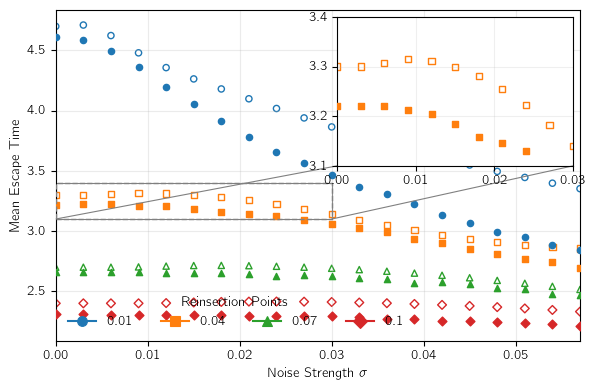

In [66]:
from matplotlib.ticker import MultipleLocator

fig, ax, axins = plot_means_with_inset(
    means_ana=None,
    means=means,
    reinsert_TO=reinsert_TO,
    sigmas=sigmas,
    s=20,
    figsize=(6, 4),
    inset_coords=(0.0, 0.03, 3.1, 3.4),
    inset_width="45%",
    inset_height="45%",
    legend_loc="lower left",
    legend_ncol=4,
    axinset_xticks=MultipleLocator(0.01),
    axinset_yticks=MultipleLocator(0.1),
    reinsertion_points=reinsertion_radii,
    dt_lower=dt_higher
)
# plt.savefig("../../Toy3d_AnaVSTraj.pdf", dpi=600, bbox_inches="tight")

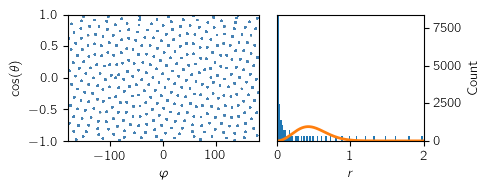

In [67]:
fig, ax = scatter_sphere_sampling(
    full_traj[:, 0, :], size=2, alpha=1, figsize=(5, 2))
fig, ax2 = add_radius_histogram_to_right(
    fig, full_traj[:, 0, :], param=3e-1, bins=100, r_max=2)

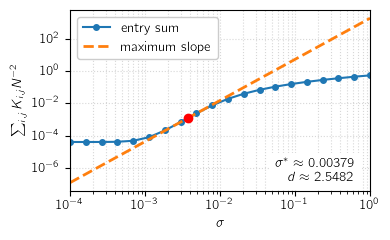

In [68]:
X = full_traj[:, 0, :]

# manually set sigmas (example: log-spaced around data scale)
sigmas_loglog = np.logspace(-4, 0, 20)

eps_vals = 2.0 * (dt_higher) * sigmas_loglog**2
# compute sums
sums = np.array([affinity_entry_sum(X, eps, chunk=1000)
                for eps in eps_vals]) / X.shape[0]**2
plot_loglog_slope_analysis(sigmas_loglog, sums)

In [54]:
fig, ax = plot_multiple_sigmas(times, full_traj,
                               [0.0],
                               n_cols=1, figsize=(5, 3),
                               reset_times_per_path=reset_times_per_path,
                               in3d=True, show_reinserts=False)
for axis in ax:
    axis.set_xlim(0, times[-1])
ax[0].set_title("")
ax[0].legend(loc="upper right")
# plt.savefig("../../Toy3dFullTraj.pdf", bbox_inches="tight", dpi=600)

NameError: name 'reset_times_per_path' is not defined

## Regime quantities
### Monte Carlo

In [29]:
rng = np.random.default_rng(42)
sigmas = np.linspace(0.0, 0.3, 101, dtype=np.float32)
dt_compare = 1e-1
reset_scale = 5e-3
times, states, sigma_arr = simulate_trajectories_per_sigma_3d(
    sigmas=sigmas,
    dt=dt_compare,
    n_steps=int(2e4) - 1,
    reset_sampler=lambda rng, size: normal_reset_sampler_vectorized_3d(
        rng, size, scale=reset_scale
    ),
    rng=rng,
    save_every=save_every,
    x0=np.array([1e-5]*3, dtype=np.float32),
    dtype=np.float32
)

In [30]:
escape_times_per_sigma = compute_lifetimes_per_sigma_3d(
    states, sigma_arr, reset_threshold=2.0, hit_threshold=1.0)
escape_times_per_sigma = {sig: [et*dt_compare for et in ets]
                          for sig, ets in escape_times_per_sigma.items()}

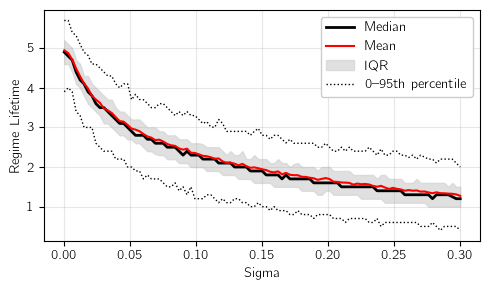

In [31]:
fig, ax = plot_lifetime_distributions_lines(
    {0: escape_times_per_sigma}, regime=0, logx=False)

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='$\\cos(\\theta)$'>)

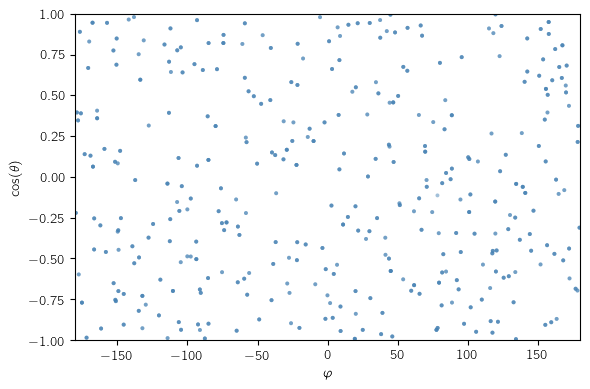

In [32]:
reinserts = np.where(np.linalg.norm(states[:, -1, :], axis=1) > 2.0)[0] + 1
scatter_sphere_sampling(states[reinserts, 0, :])

# TO Methods

In [22]:
times, states, sigma_arr = simulate_trajectories_per_sigma_3d(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt_compare,
    n_steps=int(2e4) - 1,
    reset_sampler=lambda rng, size: normal_reset_sampler_vectorized_3d(
        rng, size, scale=reset_scale
    ),
    rng=rng,
    save_every=save_every,
    x0=np.array([1e-5]*3, dtype=np.float32),
    dtype=np.float32
)

In [23]:
blocking_mask = (np.linalg.norm(
    states[:-1, 0, :], axis=-1) < 1.0).ravel().astype(bool)
resets = np.where(np.linalg.norm(
    states[:-1, 0, :], axis=-1) > 2.0)[0] + 1
resets_in_block_idx = np.nonzero(
    np.isin(np.nonzero(blocking_mask)[0], resets))[0]
eps_values = (2 * (dt_compare) * sigmas**2)

In [24]:
states[resets, 0, :].shape

(344, 3)

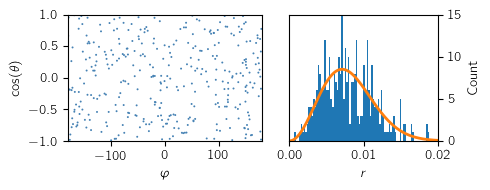

In [25]:
fig, ax = scatter_sphere_sampling(
    states[resets, 0, :], size=2, alpha=1, figsize=(5, 2))
fig, ax2 = add_radius_histogram_to_right(
    fig, states[resets, 0, :], param=reset_scale, bins=100, r_max=0.02)
plt.savefig("../../Toy3dSamplingDist.pdf", bbox_inches="tight", dpi=600)

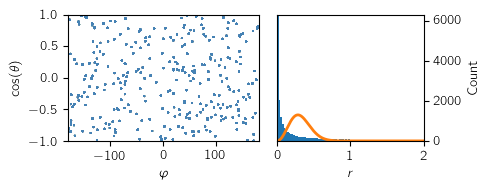

In [11]:
fig, ax = scatter_sphere_sampling(
    states[:, 0, :], size=2, alpha=1, figsize=(5, 2))
fig, ax2 = add_radius_histogram_to_right(
    fig, states[:, 0, :], param=reset_scale*100, bins=100, r_max=2)

### Check loglog plot

In [12]:
X = states[:, 0, :]

# manually set sigmas (example: log-spaced around data scale)
sigmas_loglog = np.logspace(-3, 0, 20)

eps_vals = 2.0 * (dt_compare) * sigmas_loglog**2
# compute sums
sums = np.array([affinity_entry_sum(X, eps, chunk=1000)
                for eps in eps_vals]) / X.shape[0]**2

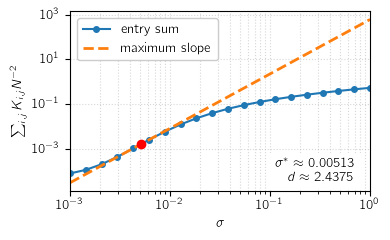

In [13]:
plot_loglog_slope_analysis(sigmas_loglog, sums)
plt.savefig("../../Toy3d_SigmaSlopeAnalysis.pdf", bbox_inches="tight", dpi=600)

### Null test: densely packed sphere

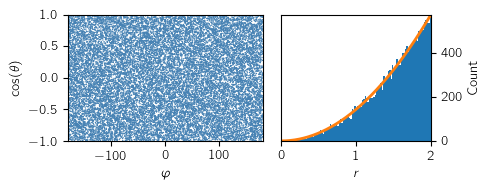

In [91]:
def sample_sphere_uniform(N, R):
    # sample radius ~ r^3 uniformly
    u = np.random.random(N)
    r = R * u**(1/3)

    # random directions
    vec = np.random.normal(size=(N, 3))
    vec /= np.linalg.norm(vec, axis=1)[:, None]

    return r[:, None] * vec


points = sample_sphere_uniform(int(2e4), 2)
fig, ax = scatter_sphere_sampling(
    points, size=1, alpha=1, figsize=(5, 2))
fig, ax2 = add_radius_histogram_to_right(
    fig, points, param=2, pdf="uniform", bins=100)

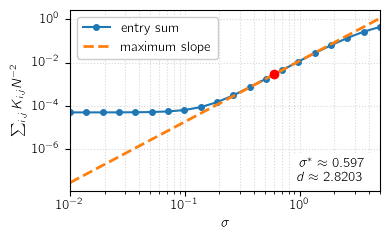

In [60]:
sums = np.array([affinity_entry_sum(points, eps, chunk=1000)
                for eps in eps_vals]) / points.shape[0]**2
plot_loglog_slope_analysis(sigmas_loglog, sums)

### Now with radial scaling

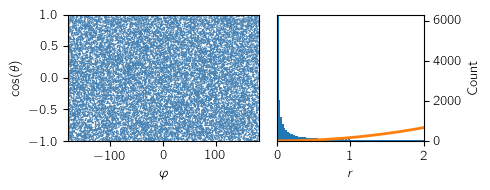

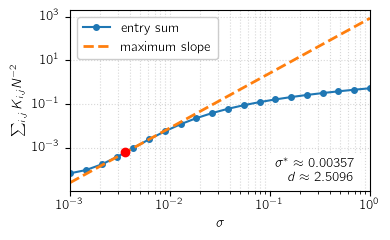

In [14]:
def shuffle_directions_flat(points):
    """
    points: array shape (N, 3)
    returns: same shape, same radii, random directions
    """
    N = points.shape[0]
    radii = np.linalg.norm(points, axis=1)

    dirs = np.random.normal(size=(N, 3))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)

    return radii[:, None] * dirs


control_states = shuffle_directions_flat(states[:, 0, :])
fig, ax = scatter_sphere_sampling(
    control_states, size=1, alpha=1, figsize=(5, 2))
fig, ax2 = add_radius_histogram_to_right(
    fig, control_states, param=2, pdf="uniform", bins=100)
sums = np.array([affinity_entry_sum(control_states, eps, chunk=1000)
                for eps in eps_vals]) / control_states.shape[0]**2
plot_loglog_slope_analysis(sigmas_loglog, sums)

### Now the lifetimes

In [17]:

regime_dict = {}
for j, eps in enumerate(eps_values):
    print(f"{j}th eps: {eps}")
    L = make_L3d(states[:, 0, :], eps)
    Q = L[blocking_mask][:, blocking_mask].tocsr()
    t_escape = solve_escape_from_Q(Q)
    regime_dict[eps] = t_escape[resets_in_block_idx].mean() * dt_compare
    print(f"Mean escape time: {regime_dict[eps]}")

0th eps: 0.0
[sparse-direct] used splu (n=17640, nnz=17342, density=5.573e-05).
Mean escape time: 5.902356902356903
1th eps: 1.8000000636675395e-06
[sparse-direct] used splu (n=17640, nnz=2020708, density=0.006494).
Mean escape time: 5.6319719636983585
2th eps: 7.200000254670158e-06
[sparse-direct] used splu (n=17640, nnz=9153597, density=0.02942).
Mean escape time: 5.236532785596938
3th eps: 1.619999784452375e-05
[iterative] GMRES converged with ILU preconditioner (n=17640, nnz=17646810, density=0.05671).
Mean escape time: 4.933668523249085
4th eps: 2.8800001018680632e-05
[iterative] GMRES converged with ILU preconditioner (n=17640, nnz=25634342, density=0.08238).
Mean escape time: 4.698959601587164
5th eps: 4.5000000682193786e-05
[iterative] GMRES converged with ILU preconditioner (n=17640, nnz=32899814, density=0.1057).
Mean escape time: 4.509547730658186
6th eps: 6.4799991378095e-05
[iterative] GMRES converged with ILU preconditioner (n=17640, nnz=39515548, density=0.127).
Mean esc

KeyboardInterrupt: 

In [ ]:
with open("./Toy3d_RegimeTimeTO.pkl", "wb") as f:
    pickle.dump(regime_dict, f)

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12458/167804331.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")


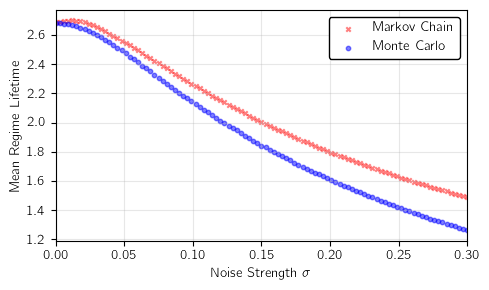

In [164]:
with open("./Toy3d_RegimeTimeTO.pkl", "rb") as f:
    regime_dict = pickle.load(f)


means = np.array([np.mean(v)
                 for k, v in sorted(escape_times_per_sigma.items())])
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.sqrt(np.array(sorted(regime_dict.keys())) / (dt_compare*2)),
           np.array([regime_dict[k]
                     for k in sorted(regime_dict.keys())]),
           color='red', marker='x', s=10, alpha=.5, label='Markov Chain')
ax.scatter(np.asarray(sorted(escape_times_per_sigma.keys()), dtype=float), means,
           color='blue', s=10, alpha=0.5, label='Monte Carlo')
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Mean Regime Lifetime")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, sigmas[-1])

ax.legend(facecolor='white', edgecolor='black', loc='best', framealpha=1)
plt.tight_layout()
plt.savefig("../../Toy3d_MeanRegimeLifetimeComparison.pdf",
            dpi=600, bbox_inches="tight")

## Go into detail for sigma=0 (det)

(0.0, 10.0)

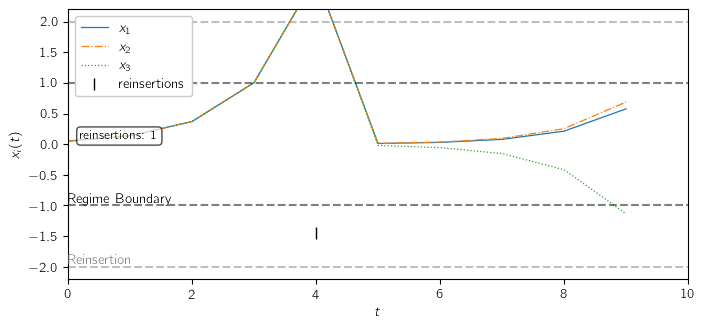

In [ ]:
times, det_traj, sigma_arr, noise = simulate_trajectories_per_sigma_3d(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=1,
    n_steps=int(2e4) - 1,
    reset_sampler=normal_reset_sampler_vectorized_3d,
    rng=rng,
    save_every=save_every,
    x0=np.array([0.05, 0.05, 0.05],),
    dtype=np.float32
)
fig, ax = plt.subplots(figsize=(8, 3.5))
reset_times_per_path = [
    times[:10][np.linalg.norm(det_traj[:10, j, :], axis=1) > 2.0]
    for j in range(det_traj.shape[1])]
plot_trajectory_with_reinsertions_3d(
    ax, times[:10], det_traj[:10], reset_times_per_path[0])
ax.set_xlim(0, times[10])

## Is the ball sampled homogeneously?

In [ ]:
n_samples = 10000
random_directions = np.random.randn(n_samples, 3)
random_directions /= np.linalg.norm(
    random_directions, axis=1, keepdims=True
)

visualize_sphere_sampling(random_directions, n_phi_bins=9, n_theta_bins=18)
scatter_sphere_sampling(random_directions)
print(direction_homogeneity_metric(
    random_directions, n_theta_bins=9, n_phi_bins=18))
print(direction_homogeneity_ratio(
    random_directions, n_theta_bins=9, n_phi_bins=18, n_reference_samples=100))

(20000, 1, 3)

0.22944369679727533
2.5634402952811137


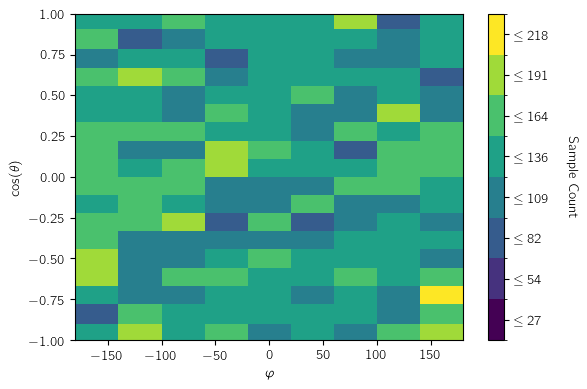

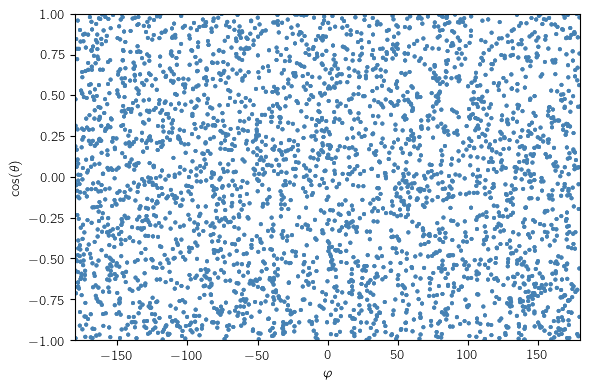

In [251]:
visualize_sphere_sampling(det_traj[:, 0, :], n_phi_bins=9, n_theta_bins=18)
scatter_sphere_sampling(det_traj[:, 0, :])
print(direction_homogeneity_metric(
    det_traj[:, 0, :], n_theta_bins=9, n_phi_bins=18))
print(direction_homogeneity_ratio(
    det_traj[:, 0, :], n_theta_bins=9, n_phi_bins=18, n_reference_samples=100))

0.8657944328765346
4.801250846473896


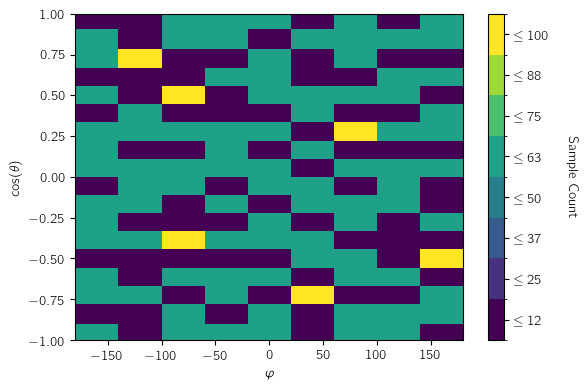

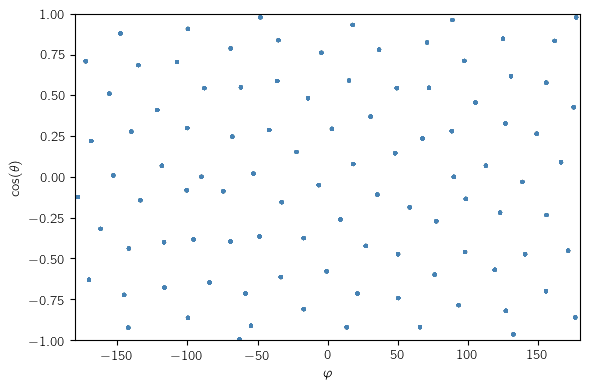

In [304]:
visualize_sphere_sampling(full_traj[:, 0, :], n_phi_bins=9, n_theta_bins=18)
scatter_sphere_sampling(full_traj[:, 0, :])
print(direction_homogeneity_metric(
    full_traj[:, 0, :], n_theta_bins=9, n_phi_bins=18))
print(direction_homogeneity_ratio(
    full_traj[:, 0, :], n_theta_bins=9, n_phi_bins=18, n_reference_samples=100))